In [159]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

TASK 1. Загрузите изображение в оттенках серого sar_1_gray.jpg

In [160]:
image = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

Text(0.5, 1.0, 'Original')

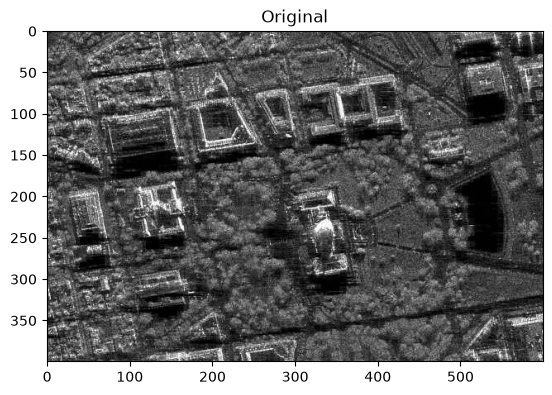

In [161]:
plt.imshow(image, cmap='gray'); plt.title("Original")

TASK 2. Постройте гистограмму

In [162]:
histSize = 256
histRange = (0, 256)
hist = cv2.calcHist([image], [0], None, [histSize], histRange)

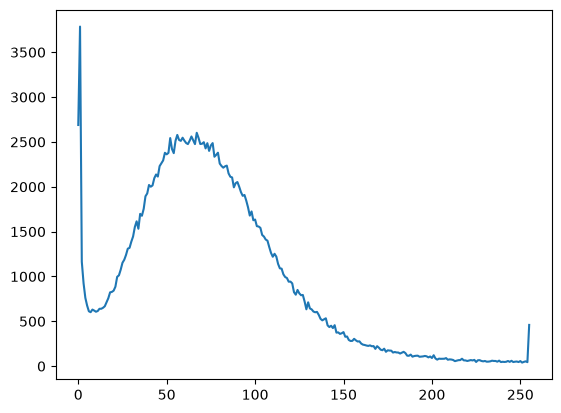

In [163]:
plt.plot(hist)

TASK 3. Реализуйте алгоритм гамма коррекции с параметром гамма <1, >1

In [164]:
def gamma_correction(image, gamma=1.0):
    return (np.power(image/255, gamma) * 255).astype(np.uint8)
img_less_than_1 = gamma_correction(image, 0.5)
img_greater_than_1 = gamma_correction(image, 1.5)


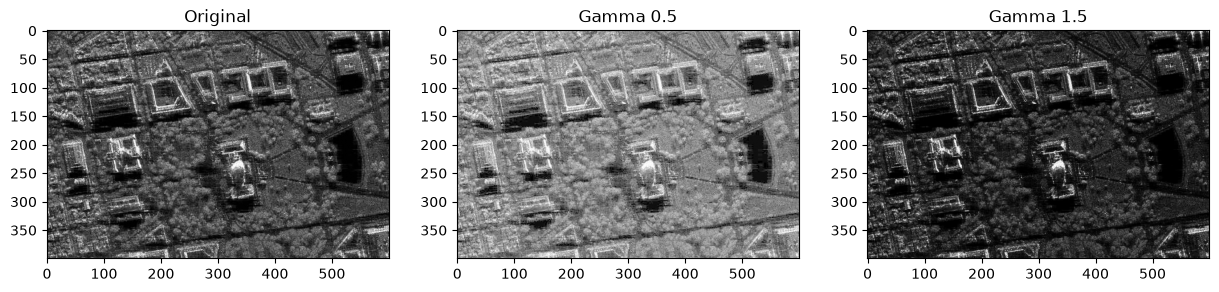

In [165]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1); plt.imshow(image, cmap='gray'); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(img_less_than_1, cmap='gray'); plt.title("Gamma 0.5")
plt.subplot(1,3,3); plt.imshow(img_greater_than_1, cmap='gray'); plt.title("Gamma 1.5")

plt.show()

TASK 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM

In [166]:
ssim1 = structural_similarity(image, img_less_than_1, data_range = 255)
mse1 = mean_squared_error(image, img_less_than_1)

In [167]:
print(f"SSIM: {ssim1:.4f}", f"MSE: {mse1:.2f}", "gamma = 0.5")

SSIM: 0.7875 MSE: 3250.43 gamma = 0.5


In [168]:
ssim2 = structural_similarity(image, img_greater_than_1, data_range = 255)
mse2 = mean_squared_error(image, img_greater_than_1)

In [169]:
print(f"SSIM: {ssim2:.4f}", f"MSE: {mse2:.2f}", "gamma = 1.5")

SSIM: 0.8066 MSE: 971.82 gamma = 1.5


TASK 5. Реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray

In [170]:
def equalize(img):
    hist, _ = np.histogram(img.ravel(), bins=256, range=[0, 256])
    cumsum = hist.cumsum()
    mcumsum = cumsum[cumsum > 0].min()
    pixels = img.shape[0]*img.shape[1]
    equalized = np.round((cumsum - mcumsum) / (pixels - mcumsum) * 255).astype(np.uint8)
    return equalized[img]
    
eq_image = equalize(image)

Text(0.5, 1.0, 'eq_image')

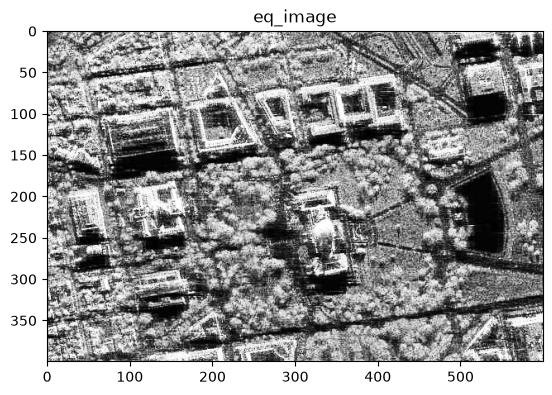

In [171]:
plt.imshow(eq_image, cmap='gray');plt.title("eq_image")

In [172]:
mean, std = image.mean(), image.std()
mean_target, std_target = eq_image.mean(), eq_image.std()
corrected = (image - mean) * (std_target / std) + mean_target
corrected = np.clip(corrected, 0, 255).astype(np.uint8)

print(f"Original: mean = {mean:.2f}, std = {std:.2f}")
print(f"Equalized: mean = {mean_target:.2f}, std = {std_target:.2f}")
print(f"Corrected: mean = {corrected.mean():.2f}, std = {corrected.std():.2f}")

Original: mean = 74.94, std = 43.66
Equalized: mean = 127.03, std = 74.27
Corrected: mean = 123.12, std = 65.30


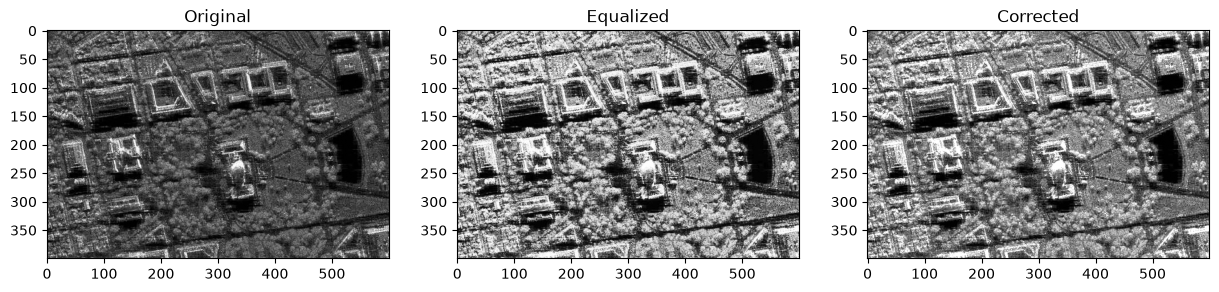

In [173]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1); plt.imshow(image, cmap='gray'); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(eq_image, cmap='gray'); plt.title("Equalized")
plt.subplot(1,3,3); plt.imshow(corrected, cmap='gray'); plt.title("Corrected")

plt.show()

TASK 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами

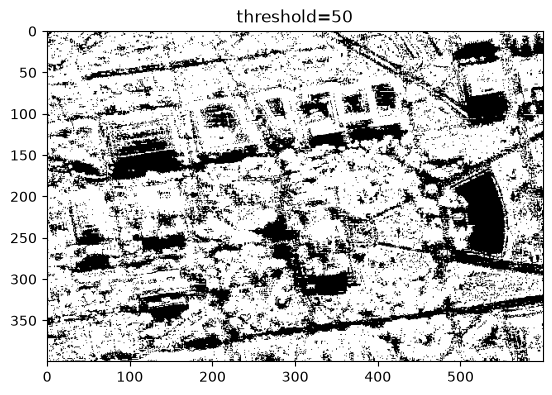

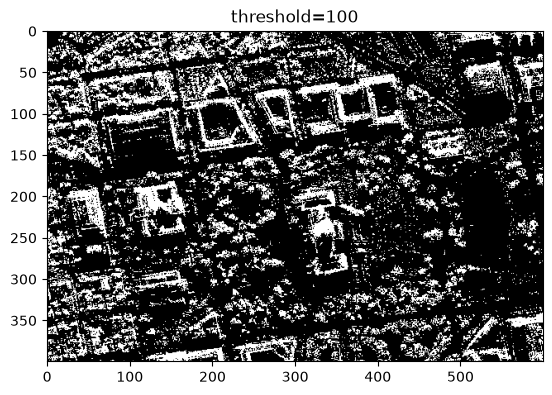

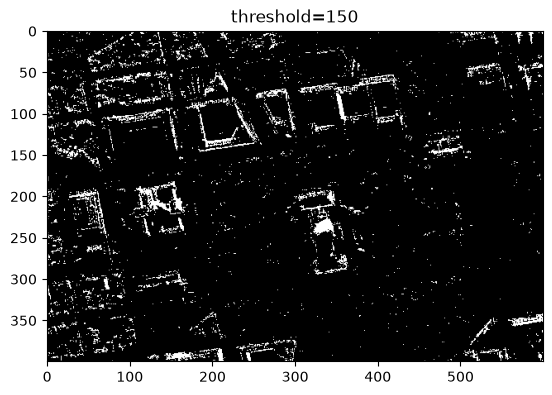

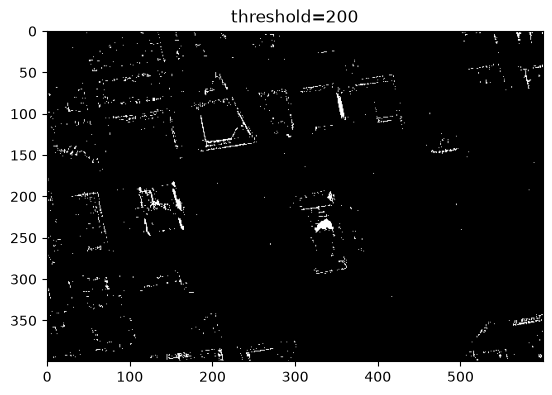

In [174]:
thresholds = [50, 100, 150, 200]

for t in thresholds:
    _, t_image = cv2.threshold(image, t, 255, cv2.THRESH_BINARY)
    plt.imshow(t_image, cmap='gray');plt.title(f"threshold={t}")
    plt.show()